# The GNN retrained for fusion

This model is different because it is trained on the intersection of participants between the original tabular and GNN models. Needs to be retrained on the exact same subset so that fusion will work.

## Setup

In [1]:
# Get content from Drive
from google.colab import drive
drive.mount('/content/drive')

# Get GitHub token from Colab secrets
from google.colab import userdata
token = userdata.get('github_token')

# Clone the repo if it doesn't exist. Pull the latest otherwise
import os
if not os.path.exists('/content/agnn'):
    !git clone https://{token}@github.com/charlottedavidson524/alzheimers-gnn.git /content/agnn
%cd /content/agnn
!git pull

# nstall project. Need to do this after a fresh clone
!pip install -e . --quiet
!pip install torch-geometric --quiet

# Copy subject-level graphs to local storage for faster access
if not os.path.exists("/content/graphs_subject"):
    !cp -r /content/drive/MyDrive/alzheimers-gnn-data/graphs_subject /content/graphs_subject
if not os.path.exists("/content/participants.tsv"):
    !cp /content/drive/MyDrive/alzheimers-gnn-data/participants.tsv /content/participants.tsv

# GPU check
import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Not available'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/agnn
Already up to date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for agnn (pyproject.toml) ... done
GPU: Tesla T4


Now that everything is setup correctly, move onto the imports

In [2]:
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, confusion_matrix
from agnn.paths import get_results_root
from agnn.gnn.model import MultiBandGCN
from agnn.gnn.data import load_subject_graphs, pair_by_subject, make_cv_splits, make_dataloader, verify_no_subject_leakage
from agnn.gnn.train import train_fold, set_seed

# Check what device is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Make sure thius points at the subject level graphs directory, not per epoch
GRAPHS_ROOT = Path("/content/graphs_subject")
print(f"Graphs root: {GRAPHS_ROOT}")

Device: cuda
Graphs root: /content/graphs_subject


Using cuda and is pointing at subject level graphs directory.

In [3]:
import json

# Load shared CV splits from the file that has been committed in git. This notebook as well as scripts/rerun_tabular_for_fusion.py load from the same source
with open("/content/agnn/data/shared_cv_splits.json") as f:
    splits_data = json.load(f)

intersection_subjects = splits_data["subjects"]

print(f"Intersection cohort: {len(intersection_subjects)} subjects")
print(f"First 3: {intersection_subjects[:3]}")
print(f"Last 3: {intersection_subjects[-3:]}")

# Load graphs for just the intersection cohort (not all 77)
graphs = load_subject_graphs(intersection_subjects, GRAPHS_ROOT)
pairs = pair_by_subject(graphs)

# Summary of the cohort
n_positive = sum(p[2] for p in pairs)
print(f"\nTotal pairs: {len(pairs)}")
print(f"Positive class (carriers): {n_positive} ({n_positive/len(pairs):.1%})")
print(f"Negative class (non-carriers): {len(pairs)-n_positive} ({(len(pairs)-n_positive)/len(pairs):.1%})")

Intersection cohort: 74 subjects
First 3: ['sub-01', 'sub-02', 'sub-03']
Last 3: ['sub-76', 'sub-77', 'sub-78']

Total pairs: 74
Positive class (carriers): 43 (58.1%)
Negative class (non-carriers): 31 (41.9%)


Move on to creating CV splits.

In [4]:
# Convert JSON subject-ID splits to index-based splits which will be compatible with the training loop. The JSON has train_subjects and val_subjects as lists
# of strings but the training loop expects positions in the pairs list
subject_to_pair_idx = {p[0].subject_id: i for i, p in enumerate(pairs)}

# Accumulate the (train_idx, val_idx) tuples for each fold
splits = []

# Iterate through each fold's subject IDs and translate them to index positions in pairs
for fold_dict in splits_data["folds"]:
    train_idx = np.array([subject_to_pair_idx[s] for s in fold_dict["train_subjects"]])
    val_idx = np.array([subject_to_pair_idx[s] for s in fold_dict["val_subjects"]])
    splits.append((train_idx, val_idx))

print(f"Converted {len(splits)} folds from subject IDs to index positions")

# Report the fold sizes so they can be sanity checked against the shared splits file
for fold_idx, (train_idx, val_idx) in enumerate(splits):
    print(f"Fold {fold_idx}: {len(train_idx)} train, {len(val_idx)} val")

# Create a timestamped results directory in Drive. Make sure this is distinct from the original run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = get_results_root()/f"run_subject_shared_splits_{timestamp}"
run_dir.mkdir(parents=True, exist_ok=True)

print(f"\nResults will save to: {run_dir}")

# Best hyperparameters from tuning (from tune_subject_20260804_193105)
config = {
    "hidden_channels": 32,
    "embedding_dim": 32,
    "mlp_hidden": 32,
    "dropout": 0.6,
    "learning_rate": 3e-4,
    "weight_decay": 1e-3,
    "batch_size": 8,
    "epochs": 300,
    "patience": 20,
    "class_weights": [1.5, 1.0],
    "n_folds": 5,
    "seed": 42,
    "aggregation": "subject-level",
    "cohort": "intersection_N74",
}

# Persist the config to the disk so any future runs can reference the exact hyperparameters used here
with open(run_dir/"config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"Config saved")

Converted 5 folds from subject IDs to index positions
Fold 0: 59 train, 15 val
Fold 1: 59 train, 15 val
Fold 2: 59 train, 15 val
Fold 3: 59 train, 15 val
Fold 4: 60 train, 14 val

Results will save to: /content/drive/MyDrive/alzheimers-gnn-data/results/run_subject_shared_splits_20260807_140714
Config saved


Now run the CV loop

In [5]:
#
fold_results = []

#
for fold_idx, (train_idx, val_idx) in enumerate(splits):
    print(f"\n{'='*60}")
    print(f"Fold {fold_idx+1}/{config['n_folds']}")
    print(f"{'='*60}")

    #
    verify_no_subject_leakage(pairs, train_idx, val_idx)

    # Report fold composition
    train_labels = [pairs[i][2] for i in train_idx]
    val_labels = [pairs[i][2] for i in val_idx]
    train_subjects = {pairs[i][0].subject_id for i in train_idx}
    val_subjects = {pairs[i][0].subject_id for i in val_idx}

    print(f"Train: {len(train_idx)} pairs, {len(train_subjects)} subjects, {sum(train_labels)}/{len(train_labels)} positive ({sum(train_labels)/len(train_labels):.1%})")
    print(f"Val: {len(val_idx)} pairs, {len(val_subjects)} subjects, {sum(val_labels)}/{len(val_labels)} positive ({sum(val_labels)/len(val_labels):.1%})")

    # Fresh model per fold with reproducible seeding
    set_seed(config["seed"]+fold_idx)
    model = MultiBandGCN(hidden_channels=config["hidden_channels"], embedding_dim=config["embedding_dim"], mlp_hidden=config["mlp_hidden"],
                         dropout=config["dropout"]).to(device)

    # Build train and val loaders
    train_loader = make_dataloader(pairs, train_idx, batch_size=config["batch_size"], shuffle=True)
    val_loader = make_dataloader(pairs, val_idx, batch_size=config["batch_size"], shuffle=False)

    # Create a fold directory for outputs
    fold_dir = run_dir/f"fold_{fold_idx}"
    fold_dir.mkdir(exist_ok=True)

    # Train this fold
    result = train_fold(model=model, train_loader=train_loader, val_loader=val_loader, config=config, device=device, checkpoint_path=fold_dir/"best_model.pt",
                        verbose=True)

    # Save training history for plotting curves later
    with open(fold_dir/"history.json", "w") as f:
        json.dump(result["history"], f, indent=2)

    # Save predictions at best epoch WITH subject IDs (needed for fusion). The subject IDs come from the val_idx positions in pairs, in the same order the
    # DataLoader emits them (order=indices, not shuffled)
    val_subject_ids = [pairs[i][0].subject_id for i in val_idx]
    np.savez(fold_dir/"predictions.npz", y_true=result["best_metrics"]["y_true"], y_prob=result["best_metrics"]["y_prob"], subject_ids=np.array(val_subject_ids))

    # Compute fold-level metrics
    y_true = result["best_metrics"]["y_true"]
    y_prob = result["best_metrics"]["y_prob"]
    y_pred = (y_prob > 0.5).astype(int)

    #
    fold_summary = {
        "fold": fold_idx,
        "best_auc": result["best_auc"],
        "best_epoch": result["best_epoch"],
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "n_train_subjects": len(train_subjects),
        "n_val_subjects": len(val_subjects),
    }

    #
    with open(fold_dir/"metrics.json", "w") as f:
        json.dump(fold_summary, f, indent=2)

    #
    fold_results.append(fold_summary)

    print(f"\nFold {fold_idx+1} complete: AUC = {result['best_auc']:.4f} at epoch {result['best_epoch']}")


Fold 1/5
Train: 59 pairs, 59 subjects, 34/59 positive (57.6%)
Val: 15 pairs, 15 subjects, 9/15 positive (60.0%)
Epoch   1/300: train_loss=0.6919, val_loss=0.7002, val_auc=0.3704
Epoch   2/300: train_loss=0.6927, val_loss=0.7000, val_auc=0.3704
Epoch   3/300: train_loss=0.6937, val_loss=0.6999, val_auc=0.3704
Epoch   4/300: train_loss=0.6944, val_loss=0.6997, val_auc=0.3704
Epoch   5/300: train_loss=0.6891, val_loss=0.6995, val_auc=0.3704
Epoch   6/300: train_loss=0.6925, val_loss=0.6995, val_auc=0.3704
Epoch   7/300: train_loss=0.6987, val_loss=0.6994, val_auc=0.3704
Epoch   8/300: train_loss=0.6957, val_loss=0.6991, val_auc=0.3704
Epoch   9/300: train_loss=0.6894, val_loss=0.6990, val_auc=0.3704
Epoch  10/300: train_loss=0.6968, val_loss=0.6986, val_auc=0.3704
Epoch  11/300: train_loss=0.6914, val_loss=0.6983, val_auc=0.3704
Epoch  12/300: train_loss=0.6919, val_loss=0.6981, val_auc=0.3704
Epoch  13/300: train_loss=0.6954, val_loss=0.6979, val_auc=0.3704
Epoch  14/300: train_loss=0.6

Below is the aggregated cross fold metrics

In [7]:
# Build cross-fold summary df
summary_df = pd.DataFrame(fold_results)
summary_df.to_csv(run_dir/"cross_fold_metrics.csv", index=False)
print("Cross-fold metrics:")
print(summary_df.to_string(index=False))

# Create overall statistics
mean_auc = summary_df["best_auc"].mean()
std_auc = summary_df["best_auc"].std()
mean_f1 = summary_df["f1"].mean()

# Show a printed summary
print(f"\n{'='*60}")
print(f"Cross-fold summary (subject level, n_folds={config['n_folds']})")
print(f"{'='*60}")
print(f"AUC: {mean_auc:.4f} +/- {std_auc:.4f}")
print(f"F1: {mean_f1:.4f} +/- {summary_df['f1'].std():.4f}")
print(f"Precision: {summary_df['precision'].mean():.4f} +/- {summary_df['precision'].std():.4f}")
print(f"Recall: {summary_df['recall'].mean():.4f} +/- {summary_df['recall'].std():.4f}")

# Save top-level summary
top_summary = {
    "config": config,
    "aggregation": "subject-level",
    "n_subjects": len(intersection_subjects),
    "n_pairs": len(pairs),
    "class_balance": {
        "positive": n_positive,
        "negative": len(pairs) - n_positive,
        "ratio_pos": n_positive / len(pairs),
    },
    "cross_fold_auc": {
        "mean": float(mean_auc),
        "std": float(std_auc),
        "per_fold": summary_df["best_auc"].tolist(),
    },
    "cross_fold_f1": {
        "mean": float(mean_f1),
        "std": float(summary_df["f1"].std()),
    },
}

# Write the top level summary to the disk in Drive so it can survive session end
with open(run_dir/"summary.json", "w") as f:
    json.dump(top_summary, f, indent=2)

print(f"\nAll results saved to: {run_dir}")

Cross-fold metrics:
 fold  best_auc  best_epoch  precision  recall       f1  n_train  n_val  n_train_subjects  n_val_subjects
    0  0.648148          28   0.000000     0.0 0.000000       59     15                59              15
    1  0.839286           1   0.533333     1.0 0.695652       59     15                59              15
    2  0.518519           1   0.000000     0.0 0.000000       59     15                59              15
    3  0.537037           5   0.600000     1.0 0.750000       59     15                59              15
    4  0.395833           1   0.571429     1.0 0.727273       60     14                60              14

Cross-fold summary (subject level, n_folds=5)
AUC: 0.5878 +/- 0.1667
F1: 0.4346 +/- 0.3972
Precision: 0.3410 +/- 0.3121
Recall: 0.6000 +/- 0.5477

All results saved to: /content/drive/MyDrive/alzheimers-gnn-data/results/run_subject_shared_splits_20260807_140714


Show the training curves

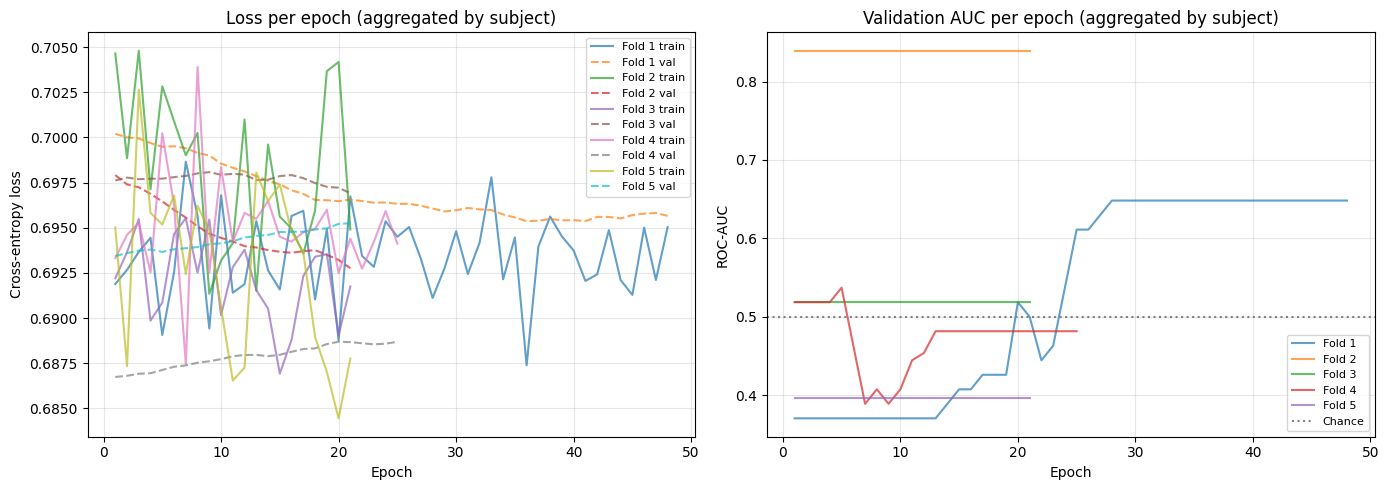

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iterate over the folds. Log each fold's saved history and plot its curves.
for fold_idx in range(config["n_folds"]):
    fold_dir = run_dir/f"fold_{fold_idx}"
    with open(fold_dir/"history.json") as f:
        history = json.load(f)

    # Left axis will be train/validation loss curves. Right will be validation AUC
    epochs = range(1, len(history["train_loss"])+1)
    axes[0].plot(epochs, history["train_loss"], label=f"Fold {fold_idx+1} train", alpha=0.7)
    axes[0].plot(epochs, history["val_loss"], label=f"Fold {fold_idx+1} val", linestyle="--", alpha=0.7)
    axes[1].plot(epochs, history["val_auc"], label=f"Fold {fold_idx+1}", alpha=0.7)

# Title, labels, legend and grid for left hand graph
axes[0].set_title("Loss per epoch (aggregated by subject)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(alpha=0.3)

# Title, labels, legend and grid for right hand graph
axes[1].set_title("Validation AUC per epoch (aggregated by subject)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].axhline(y=0.5, color="gray", linestyle=":", label="Chance")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3)

# Display and save graphs
plt.tight_layout()
plt.savefig(run_dir/"training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

ROC curves plot

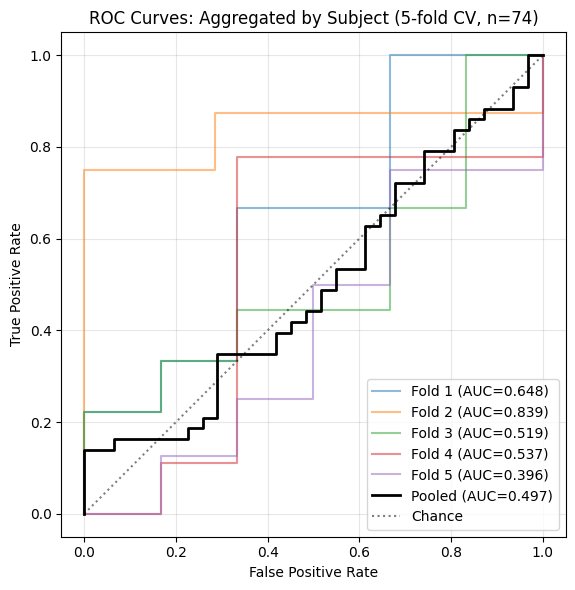

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the ROC curve for each fold individually, this shows the variation between folds
for fold_idx in range(config["n_folds"]):
    fold_dir = run_dir/f"fold_{fold_idx}"
    preds = np.load(fold_dir/"predictions.npz")
    fpr, tpr, _ = roc_curve(preds["y_true"], preds["y_prob"])
    auc = roc_auc_score(preds["y_true"], preds["y_prob"])
    ax.plot(fpr, tpr, alpha=0.5, label=f"Fold {fold_idx+1} (AUC={auc:.3f})")

# Prepare lists to collect predictions across folds for the pooled ROC
all_y_true = []
all_y_prob = []

# Load each fold's predictions and append to the running lsist
for fold_idx in range(config["n_folds"]):
    preds = np.load(run_dir/f"fold_{fold_idx}"/"predictions.npz")
    all_y_true.append(preds["y_true"])
    all_y_prob.append(preds["y_prob"])

# Flatten into single arrays covering the whole cohort
all_y_true = np.concatenate(all_y_true)
all_y_prob = np.concatenate(all_y_prob)

# Compute the pooled ROC and AUC across all folds combined
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
pooled_auc = roc_auc_score(all_y_true, all_y_prob)

# Draw the pooled ROC on top of the per-fold curves. This should give a cohort-level view
ax.plot(fpr, tpr, color="black", linewidth=2, label=f"Pooled (AUC={pooled_auc:.3f})")

# The chance line
ax.plot([0, 1], [0, 1], "k:", alpha=0.5, label="Chance")

# Labels, title, legend and grid for the plot
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves: Aggregated by Subject (5-fold CV, n={len(intersection_subjects)})")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
ax.set_aspect("equal")

# Display and save plot
plt.tight_layout()
plt.savefig(run_dir/"roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()